In [52]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [53]:
print("Loading Dataset........")
Data = pd.read_csv(
    "G:/Intern project 1/Project file/resource.csv",
    encoding='utf-8',
    encoding_errors='ignore'
)

Loading Dataset........


In [54]:
print(f"Original Dataset Shape: {Data.shape[0]} rows, {Data.shape[1]} columns")
print("\n--- Raw Data Sample ---")
print(Data.head())

Original Dataset Shape: 541909 rows, 8 columns

--- Raw Data Sample ---
  InvoiceNo StockCode                          Description  Quantity  \
0    536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER         6   
1    536365     71053                  WHITE METAL LANTERN         6   
2    536365    84406B       CREAM CUPID HEARTS COAT HANGER         8   
3    536365    84029G  KNITTED UNION FLAG HOT WATER BOTTLE         6   
4    536365    84029E       RED WOOLLY HOTTIE WHITE HEART.         6   

      InvoiceDate  UnitPrice  CustomerID         Country  
0  12/1/2010 8:26       2.55     17850.0  United Kingdom  
1  12/1/2010 8:26       3.39     17850.0  United Kingdom  
2  12/1/2010 8:26       2.75     17850.0  United Kingdom  
3  12/1/2010 8:26       3.39     17850.0  United Kingdom  
4  12/1/2010 8:26       3.39     17850.0  United Kingdom  


In [55]:
print("Converting 'InvoiceDate' to datetime format...")
Data["InvoiceDate"] = pd.to_datetime(Data["InvoiceDate"])

Converting 'InvoiceDate' to datetime format...


In [56]:
print("Cleaning invalid quantities and unit prices...")

Cleaning invalid quantities and unit prices...


In [57]:
negative_qty = (Data["Quantity"] <= 0).sum()
negative_price = (Data["UnitPrice"] <= 0).sum()
print(f"-> Found {negative_qty} rows with zero or negative Quantity (Cancellations).")
print(f"-> Found {negative_price} rows with zero or negative UnitPrice.")

-> Found 10624 rows with zero or negative Quantity (Cancellations).
-> Found 2517 rows with zero or negative UnitPrice.


In [58]:
df_cleaned = Data[(Data["Quantity"] > 0) & (Data["UnitPrice"] > 0)].copy()

In [59]:
print("\nChecking for missing values...")
print(df_cleaned.isnull().sum())


Checking for missing values...
InvoiceNo           0
StockCode           0
Description         0
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     132220
Country             0
dtype: int64


In [60]:
df_cleaned.dropna(subset=["Description"], inplace=True)

In [61]:
print("\nCalculating Total Sales (Revenue)...")
# Revenue = Quantity * UnitPrice
df_cleaned["Total_Sales"] = df_cleaned["Quantity"] * df_cleaned["UnitPrice"]


Calculating Total Sales (Revenue)...


In [62]:
print( "=" * 40)
print(
    f"Cleaned Dataset Shape: {df_cleaned.shape[0]} rows, {df_cleaned.shape[1]} columns"
)
print(f"Rows removed (Noise/Cancellations): {Data.shape[0] - df_cleaned.shape[0]}")
print("\n--- Cleaned Data Sample ---")
print(
    df_cleaned[
        [
            "InvoiceNo",
            "StockCode",
            "Quantity",
            "InvoiceDate",
            "UnitPrice",
            "Total_Sales",
        ]
    ].head()
)
print("=" * 40)


Cleaned Dataset Shape: 530104 rows, 9 columns
Rows removed (Noise/Cancellations): 11805

--- Cleaned Data Sample ---
  InvoiceNo StockCode  Quantity         InvoiceDate  UnitPrice  Total_Sales
0    536365    85123A         6 2010-12-01 08:26:00       2.55        15.30
1    536365     71053         6 2010-12-01 08:26:00       3.39        20.34
2    536365    84406B         8 2010-12-01 08:26:00       2.75        22.00
3    536365    84029G         6 2010-12-01 08:26:00       3.39        20.34
4    536365    84029E         6 2010-12-01 08:26:00       3.39        20.34


In [64]:
print("Aggregating transactional data to daily revenue...")
df_cleaned["Date"] = df_cleaned["InvoiceDate"].dt.date

Aggregating transactional data to daily revenue...


In [65]:
daily_series = (
    df_cleaned.groupby("Date")["Total_Sales"].sum().to_frame(name="Total_Sales")
)

In [66]:
daily_series.index = pd.to_datetime(daily_series.index)

print(f"Initial daily timeline length: {len(daily_series)} days.")

Initial daily timeline length: 305 days.


In [71]:
print("\nChecking for missing dates in the timeline (e.g., holidays)...")
daily_series_filled = daily_series.asfreq("D")
missing_days_count = daily_series_filled["Total_Sales"].isnull().sum()
print(f"-> Detected {missing_days_count} missing days in the original timeline.")


Checking for missing dates in the timeline (e.g., holidays)...
-> Detected 69 missing days in the original timeline.


In [72]:
daily_series_filled["Total_Sales"] = daily_series_filled["Total_Sales"].fillna(
    0
)

In [78]:
print("=" * 40)
print(f"Final continuous timeline length: {len(daily_series_filled)} days.")
print(f"Date Range: {daily_series_filled.index.min()} to {daily_series_filled.index.max()}")
print("\n--- Final Structured Time-Series Dataset Sample ---")
print(daily_series_filled.head(10))
print("="*40)

Final continuous timeline length: 374 days.
Date Range: 2010-12-01 00:00:00 to 2011-12-09 00:00:00

--- Final Structured Time-Series Dataset Sample ---
            Total_Sales
Date                   
2010-12-01     58960.79
2010-12-02     47748.38
2010-12-03     46943.71
2010-12-04         0.00
2010-12-05     31774.95
2010-12-06     54830.46
2010-12-07     99618.20
2010-12-08     45389.98
2010-12-09     53586.18
2010-12-10     59182.92


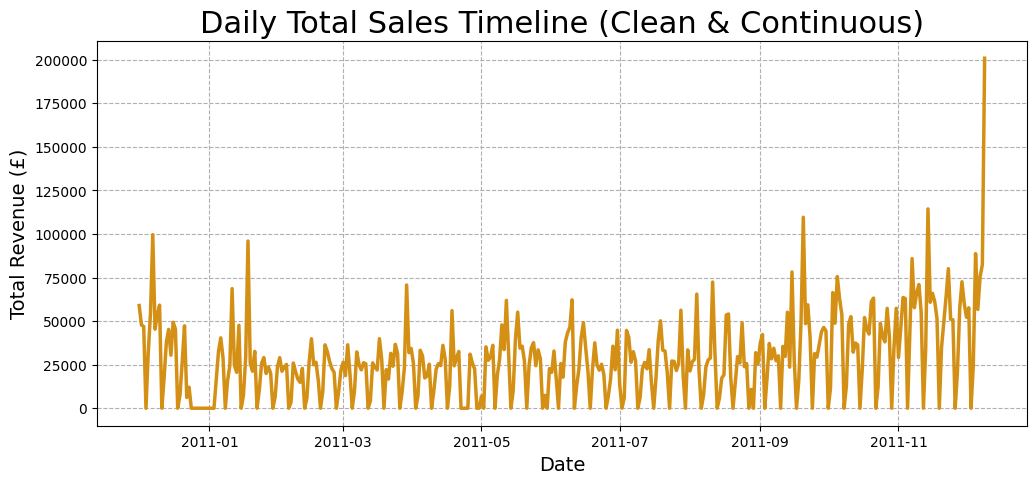

In [92]:
plt.figure(figsize=(12,5))
plt.plot(
    daily_series_filled.index,
    daily_series_filled["Total_Sales"],
    color="#D39014",
    linewidth=2.5,
)
plt.title("Daily Total Sales Timeline (Clean & Continuous)", fontsize=22)
plt.xlabel("Date", fontsize=14)
plt.ylabel("Total Revenue (£)", fontsize=14)
plt.grid(True, linestyle="--", alpha=1)
plt.show()

In [94]:
from statsmodels.tsa.seasonal import seasonal_decompose

In [97]:
print("Performing seasonal decomposition...")
decomposition = seasonal_decompose(
    daily_series_filled["Total_Sales"], model="additive", period=7
)
trend = decomposition.trend
seasonal = decomposition.seasonal
residual = decomposition.resid


Performing seasonal decomposition...



Generating EDA and Decomposition Dashboard...


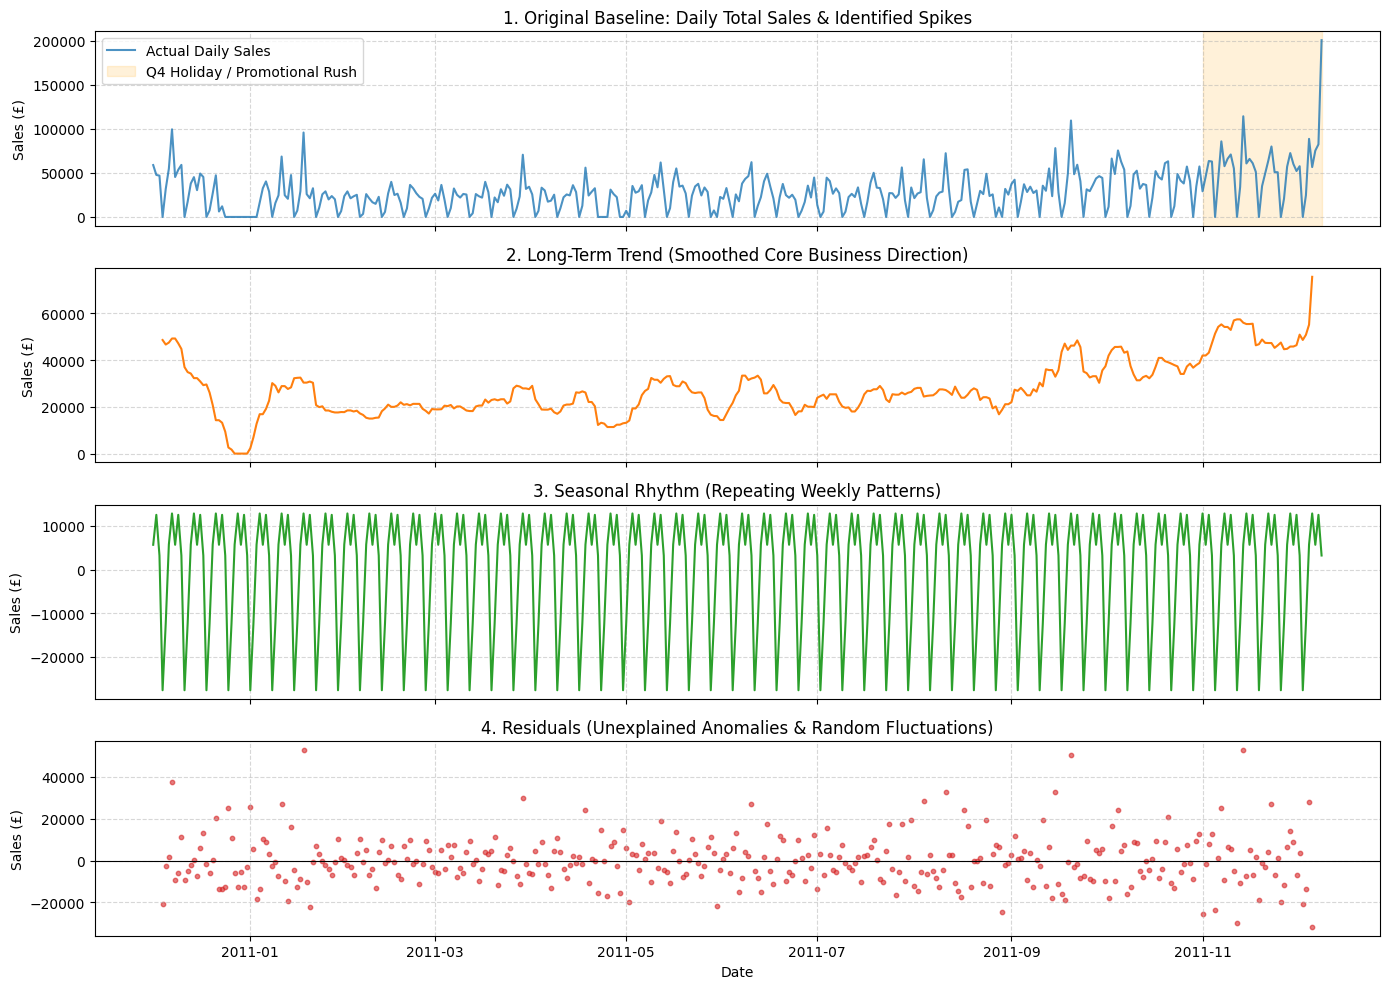

In [109]:
print("\nGenerating EDA and Decomposition Dashboard...")
fig, axes = plt.subplots(nrows=4, ncols=1, figsize=(14, 10), sharex=True)
axes[0].plot(
    daily_series_filled.index,
    daily_series_filled["Total_Sales"],
    label="Actual Daily Sales",
    color="#1f77b4",
    alpha=0.8,
)
axes[0].axvspan(
    pd.Timestamp("2011-11-01"),
    pd.Timestamp("2011-12-09"),
    color="orange",
    alpha=0.15,
    label="Q4 Holiday / Promotional Rush",
)
axes[0].set_title(
    "1. Original Baseline: Daily Total Sales & Identified Spikes", fontsize=12
)
axes[0].set_ylabel("Sales (£)")
axes[0].legend(loc="upper left")
axes[0].grid(True, linestyle="--", alpha=0.5)

#panel 2:
axes[1].plot(daily_series_filled.index, trend, label="Trend", color="#ff7f0e")
axes[1].set_title(
    "2. Long-Term Trend (Smoothed Core Business Direction)", fontsize=12
)
axes[1].set_ylabel("Sales (£)")
axes[1].grid(True, linestyle="--", alpha=0.5)

#panel3
axes[2].plot(
    daily_series_filled.index, seasonal, label="Weekly Seasonality", color="#2ca02c"
)
axes[2].set_title(
    "3. Seasonal Rhythm (Repeating Weekly Patterns)", fontsize=12
)
axes[2].set_ylabel("Sales (£)")
axes[2].grid(True, linestyle="--", alpha=0.5)

#panel
axes[3].scatter(
    daily_series_filled.index,
    residual,
    label="Residuals (Noise)",
    color="#d62728",
    s=10,
    alpha=0.6,
)
axes[3].axhline(0, color="black", linestyle="-", linewidth=0.8)
axes[3].set_title(
    "4. Residuals (Unexplained Anomalies & Random Fluctuations)", fontsize=12
)
axes[3].set_ylabel("Sales (£)")
axes[3].set_xlabel("Date")
axes[3].grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

In [110]:
print("\n" + "=" * 40)
print("STEP 3 INSIGHTS & OBSERVATIONS")
print("=" * 40)
print(
    "1. BASELINE: Look at the massive revenue spike peaks clustered between November and December."
)
print(
    "2. TREND: Notice the steady, upward macro-slope starting around August 2011."
)
print(
    "3. SEASONALITY: Zoom into chart 3; it reveals a clean, consistent 7-day cyclical heartbeat."
)


STEP 3 INSIGHTS & OBSERVATIONS
1. BASELINE: Look at the massive revenue spike peaks clustered between November and December.
2. TREND: Notice the steady, upward macro-slope starting around August 2011.
3. SEASONALITY: Zoom into chart 3; it reveals a clean, consistent 7-day cyclical heartbeat.


In [111]:
from prophet import Prophet

In [114]:
print("Formatting data for Meta Prophet...")
prophet_df = daily_series_filled.reset_index()
prophet_df.columns = ["ds", "y"]
prophet_df["ds"] = pd.to_datetime(prophet_df["ds"])

Formatting data for Meta Prophet...


In [118]:
print("\nPerforming chronological train-test split...")
split_date = pd.Timestamp("2011-10-31")
train_df = prophet_df[prophet_df["ds"] <= split_date].copy()
test_df = prophet_df[prophet_df["ds"] > split_date].copy()



Performing chronological train-test split...


In [119]:
print(f"-> Training Set Range: {train_df['ds'].min().date()} to {train_df['ds'].max().date()} ({len(train_df)} days)")
print(f"-> Testing Set Range:  {test_df['ds'].min().date()} to {test_df['ds'].max().date()} ({len(test_df)} days)")

-> Training Set Range: 2010-12-01 to 2011-10-31 (335 days)
-> Testing Set Range:  2011-11-01 to 2011-12-09 (39 days)


In [ ]:
print("\nCreating custom holiday windows for the Q4 promotional rush...")
q4_promotions = pd.DataFrame(
    {
        "holiday": "q4_holiday_rush",
        "ds": pd.to_datetime(
            [
                "2011-11-06",
                "2011-11-14",
                "2011-11-23",
                "2011-11-24",
                "2011-11-25",  # 
                "2011-12-02",
                "2011-12-05",
            ]
        ),
        "lower_window": -1,  
        "upper_window": 1,  
    }
)


Creating custom holiday windows for the Q4 promotional rush...


In [ ]:
print("\nInitializing and fitting Prophet baseline model...")
model = Prophet(
    holidays=q4_promotions,
    yearly_seasonality=False, 
    weekly_seasonality=True,
    daily_seasonality=False,
)


Initializing and fitting Prophet baseline model...


In [124]:
model.fit(train_df)

12:14:56 - cmdstanpy - INFO - Chain [1] start processing
12:14:59 - cmdstanpy - INFO - Chain [1] done processing


In [127]:
print("\nGenerating predictions across the test evaluation window...")
forecast = model.predict(test_df[["ds"]])
evaluation_df = test_df.merge(
    forecast[["ds", "yhat", "yhat_lower", "yhat_upper"]], on="ds"
)


Generating predictions across the test evaluation window...


In [129]:
evaluation_df["Absolute_Error"] = (
    evaluation_df["y"] - evaluation_df["yhat"]
).abs()
baseline_mae = evaluation_df["Absolute_Error"].mean()
print(f"Prophet Baseline Model MAE: £{baseline_mae:.2f}")
print("Meaning: On average, our initial model's daily predictions are off by roughly this amount.")



Prophet Baseline Model MAE: £21308.70
Meaning: On average, our initial model's daily predictions are off by roughly this amount.


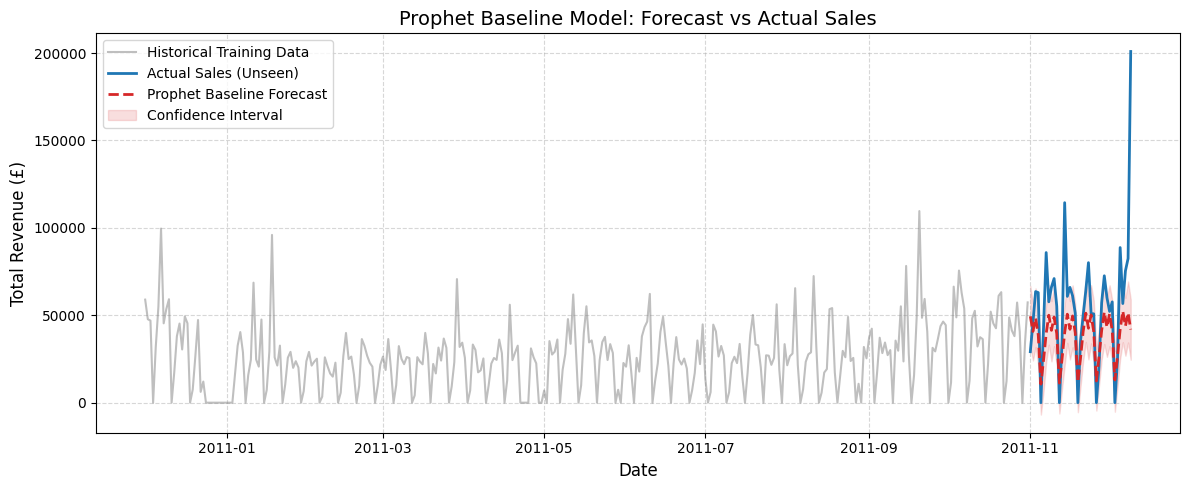

In [ ]:
plt.figure(figsize=(12, 5))
plt.plot(
    train_df["ds"], train_df["y"], label="Historical Training Data", color="gray", alpha=0.5
)
plt.plot(
    evaluation_df["ds"], evaluation_df["y"], label="Actual Sales (Unseen)", color="#1f77b4", linewidth=2
)
plt.plot(
    evaluation_df["ds"],
    evaluation_df["yhat"],
    label="Prophet Baseline Forecast",
    color="#d62728",
    linestyle="--",
    linewidth=2,
)
plt.fill_between(
    evaluation_df["ds"],
    evaluation_df["yhat_lower"],
    evaluation_df["yhat_upper"],
    color="#d62728",
    alpha=0.15,
    label="Confidence Interval",
)
plt.title("Prophet Baseline Model: Forecast vs Actual Sales", fontsize=14)
plt.xlabel("Date", fontsize=12)
plt.ylabel("Total Revenue (£)", fontsize=12)
plt.legend(loc="upper left")
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

In [131]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

In [134]:
print("Preparing continuous series for SARIMAX...")
sarimax_series = daily_series_filled["Total_Sales"]
split_date = "2011-10-31"
train_sarimax = sarimax_series[:split_date]
test_sarimax = sarimax_series[split_date:][1:]

Preparing continuous series for SARIMAX...


In [135]:
print(f"-> SARIMAX Train Shape: {train_sarimax.shape[0]} days")
print(f"-> SARIMAX Test Shape:  {test_sarimax.shape[0]} days")

-> SARIMAX Train Shape: 335 days
-> SARIMAX Test Shape:  39 days


In [137]:
print("\nFitting SARIMAX(1, 1, 1)x(0, 1, 1, 7) Model...")
sarimax_model = SARIMAX(
    train_sarimax,
    order=(1, 1, 1),
    seasonal_order=(0, 1, 1, 7),
    enforce_stationarity=False,
    enforce_invertibility=False,
)

sarimax_results = sarimax_model.fit(disp=False)
print(sarimax_results.summary())


Fitting SARIMAX(1, 1, 1)x(0, 1, 1, 7) Model...
                                     SARIMAX Results                                     
Dep. Variable:                       Total_Sales   No. Observations:                  335
Model:             SARIMAX(1, 1, 1)x(0, 1, 1, 7)   Log Likelihood               -3492.180
Date:                           Mon, 01 Jun 2026   AIC                           6992.360
Time:                                   12:20:23   BIC                           7007.408
Sample:                               12-01-2010   HQIC                          6998.370
                                    - 10-31-2011                                         
Covariance Type:                             opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.0141      0.108     -0.130      0.896      -0.226       0

In [140]:
print("\nGenerating SARIMAX future predictions...")
sarimax_forecast = sarimax_results.get_forecast(steps=len(test_sarimax))
sarimax_pred_mean = sarimax_forecast.predicted_mean
sarimax_conf_int = sarimax_forecast.conf_int()
sarimax_mae = np.mean(np.abs(test_sarimax - sarimax_pred_mean))


Generating SARIMAX future predictions...


In [141]:
print("\n" + "=" * 40)
print("SARIMAX MODEL SUMMARY")
print("=" * 40)
print(f"SARIMAX Model MAE: £{sarimax_mae:.2f}")


SARIMAX MODEL SUMMARY
SARIMAX Model MAE: £14892.33


In [142]:
from sklearn.preprocessing import MinMaxScaler
import tensorflow as tf
from tensorflow.keras.layers import LSTM, Dense
from tensorflow.keras.models import Sequential

C:\Users\omnay\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\requests\__init__.py:113: RequestsDependencyWarning: urllib3 (2.6.3) or chardet (7.4.3)/charset_normalizer (3.4.6) doesn't match a supported version!
  warnings.warn(


In [144]:
print("\nPreparing sliding sequences for LSTM network...")
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(sarimax_series.values.reshape(-1, 1))


Preparing sliding sequences for LSTM network...


In [145]:
def create_sequences(data, window_size):
    X, y = [], []
    for i in range(len(data) - window_size):
        X.append(data[i : (i + window_size)])
        y.append(data[i + window_size])
    return np.array(X), np.array(y)

In [146]:
WINDOW_SIZE = 14
X, y = create_sequences(scaled_data, WINDOW_SIZE)

In [147]:
train_size = len(sarimax_series[:split_date]) - WINDOW_SIZE

In [148]:
X_train, y_train = X[:train_size], y[:train_size]
X_test, y_test = X[train_size:], y[train_size:]

In [149]:
print("\nCompiling and training LSTM Architecture...")


Compiling and training LSTM Architecture...


In [151]:
model_lstm = Sequential(
    [
        LSTM(
            50,
            return_sequences=False,
            input_shape=(WINDOW_SIZE, 1),
            activation="relu",
        ),
        Dense(25, activation="relu"),
        Dense(1),  # Output layer predicting the single next value
    ]
)
model_lstm.compile(optimizer="adam", loss="mean_squared_error")

In [152]:
history = model_lstm.fit(
    X_train,
    y_train,
    batch_size=4,
    epochs=15,
    validation_data=(X_test, y_test),
    verbose=0,
)

In [155]:
print("\nInverting predictions back to actual currency values...")
lstm_predictions = model_lstm.predict(X_test, verbose=0)
lstm_predictions_unscaled = scaler.inverse_transform(lstm_predictions).flatten()
actual_test_values = scaler.inverse_transform(y_test).flatten()


Inverting predictions back to actual currency values...


In [156]:
lstm_mae = np.mean(np.abs(actual_test_values - lstm_predictions_unscaled))

print("\n" + "=" * 40)
print("LSTM MODEL SUMMARY")
print("=" * 40)
print(f"LSTM Deep Learning Model MAE: £{lstm_mae:.2f}")


LSTM MODEL SUMMARY
LSTM Deep Learning Model MAE: £23274.03


In [157]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [162]:
print("Aligning predictions for evaluation...")
actual_sales = test_sarimax.values
dates_eval = test_sarimax.index
prophet_preds = evaluation_df["yhat"].values[: len(actual_sales)]
sarimax_preds = sarimax_pred_mean.values[: len(actual_sales)]
lstm_preds = lstm_predictions_unscaled[: len(actual_sales)]

Aligning predictions for evaluation...


In [169]:
print("\nCalculating performance metrics...")

metrics_summary = {
    "Model": ["Meta Prophet", "SARIMAX", "LSTM Neural Network"],
    "MAE (Mean Absolute Error)": [
        mean_absolute_error(actual_sales, prophet_preds),
        mean_absolute_error(actual_sales, sarimax_preds),
        mean_absolute_error(actual_sales, lstm_preds),
    ],
    "RMSE (Root Mean Squared Error)": [
        np.sqrt(mean_squared_error(actual_sales, prophet_preds)),
        np.sqrt(mean_squared_error(actual_sales, sarimax_preds)),
        np.sqrt(mean_squared_error(actual_sales, lstm_preds)),
    ],
}
metrics_df = pd.DataFrame(metrics_summary)


Calculating performance metrics...


In [170]:
print("\n" + "=" * 50)
print("             MODEL LEADERBOARD PERFORMANCE")
print("=" * 50)
print(metrics_df.to_string(index=False, float_format=lambda x: f"£{x:,.2f}"))
print("=" * 50)

best_model = metrics_df.loc[
    metrics_df["MAE (Mean Absolute Error)"].idxmin(), "Model"
]
print(
    f"🏆 WINNING ENGINE: {best_model} has the lowest overall error rate!"
)


             MODEL LEADERBOARD PERFORMANCE
              Model  MAE (Mean Absolute Error)  RMSE (Root Mean Squared Error)
       Meta Prophet                 £21,308.70                      £33,969.63
            SARIMAX                 £14,892.33                      £27,509.10
LSTM Neural Network                 £23,274.03                      £35,094.67
🏆 WINNING ENGINE: SARIMAX has the lowest overall error rate!



Generating final comparative visualization dashboard...


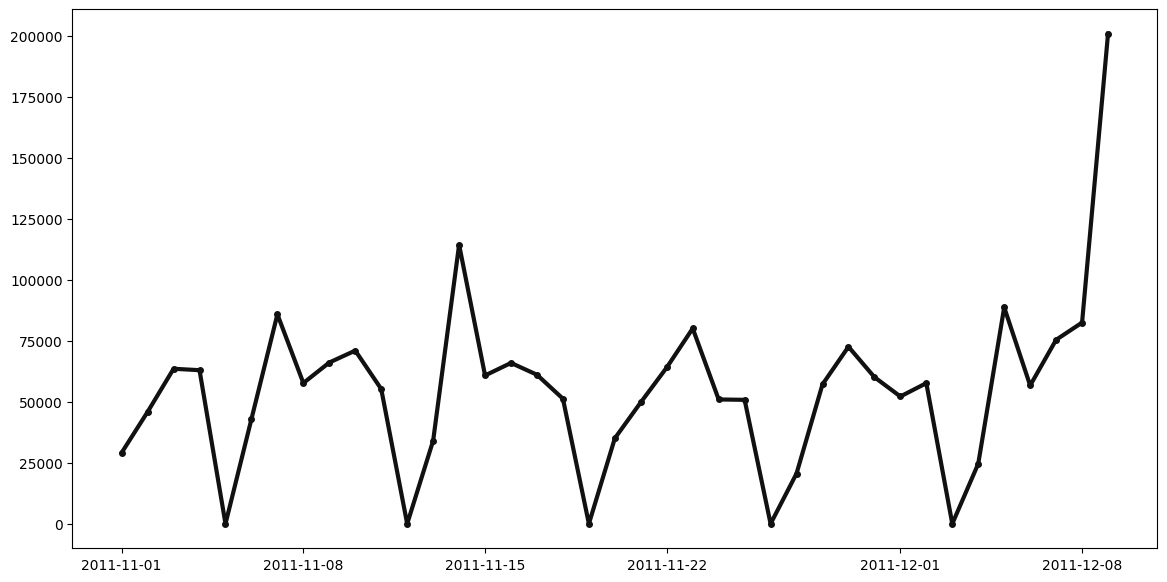

In [174]:
print("\nGenerating final comparative visualization dashboard...")
plt.figure(figsize=(14, 7))
plt.plot(
    dates_eval,
    actual_sales,
    label="Actual Sales (Ground Truth)",
    color="#111111",
    linewidth=3,
    marker="o",
    markersize=4,
)

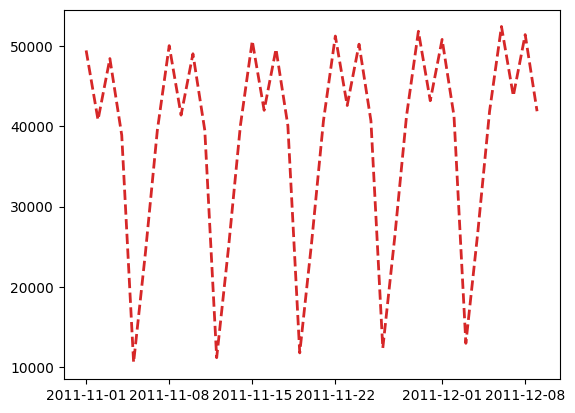

In [175]:
plt.plot(
    dates_eval,
    prophet_preds,
    label=f"Meta Prophet (MAE: £{metrics_summary['MAE (Mean Absolute Error)'][0]:,.2f})",
    color="#d62728",
    linestyle="--",
    linewidth=2,
)

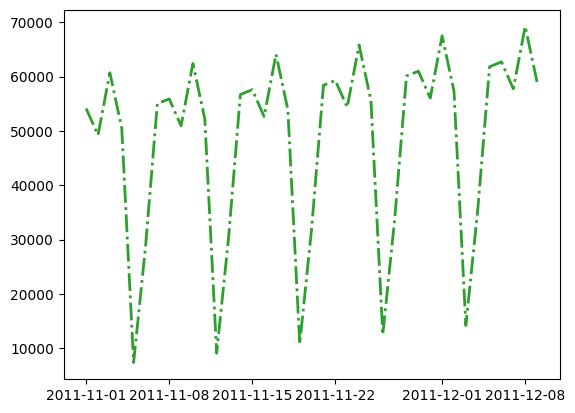

In [176]:
plt.plot(
    dates_eval,
    sarimax_preds,
    label=f"SARIMAX (MAE: £{metrics_summary['MAE (Mean Absolute Error)'][1]:,.2f})",
    color="#2ca02c",
    linestyle="-.",
    linewidth=2,
)

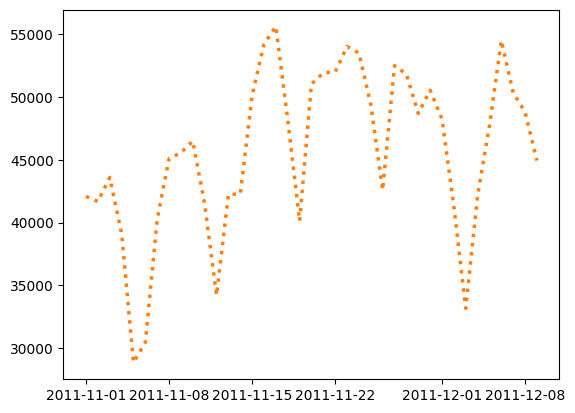

In [177]:
plt.plot(
    dates_eval,
    lstm_preds,
    label=f"LSTM Network (MAE: £{metrics_summary['MAE (Mean Absolute Error)'][2]:,.2f})",
    color="#ff7f0e",
    linestyle=":",
    linewidth=2.5,
)

C:\Users\omnay\AppData\Local\Temp\ipykernel_13616\1160388939.py:10: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc="upper left", fontsize=11, facecolor="white", edgecolor="none")


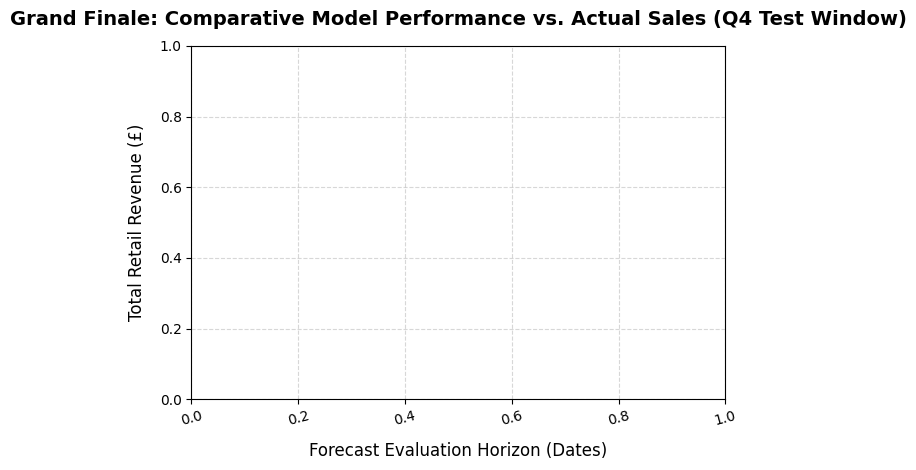

In [179]:
plt.title(
    "Grand Finale: Comparative Model Performance vs. Actual Sales (Q4 Test Window)",
    fontsize=14,
    fontweight="bold",
    pad=15,
)
plt.xlabel("Forecast Evaluation Horizon (Dates)", fontsize=12, labelpad=10)
plt.ylabel("Total Retail Revenue (£)", fontsize=12, labelpad=10)
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend(loc="upper left", fontsize=11, facecolor="white", edgecolor="none")
plt.xticks(rotation=15)
plt.tight_layout()

# Save the final masterpiece graph for your portfolio documentation!
plt.savefig("final_model_comparison_chart.png", dpi=300)
plt.show()